# Intro to Keras and tensorflow

Let's build a model to diagnose the diabetes disease based on generic information on the patient

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Access the dataset and store it in a container

In [3]:
from pathlib import Path
dataset_path = Path().resolve().parent / 'dataset'

#access the dataset and store it in a panda dataframe
df = pd.read_csv(dataset_path/'diabetes.csv')

#reshuffle the df rows
df = df.sample(frac = 1)

In [4]:
#print the first 5 rows
df[:5]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
2,8,183,64,0,0,23.3,0.672,32,1
607,1,92,62,25,41,19.5,0.482,25,0
28,13,145,82,19,110,22.2,0.245,57,0
116,5,124,74,0,0,34.0,0.220,38,1
624,2,108,64,0,0,30.8,0.158,21,0


In [5]:
#print the number of rows and columns
df.shape

(768, 9)

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Data preparation


## We notice that certain field contain null values, which is not expected in some case

Let's try to remove those lines

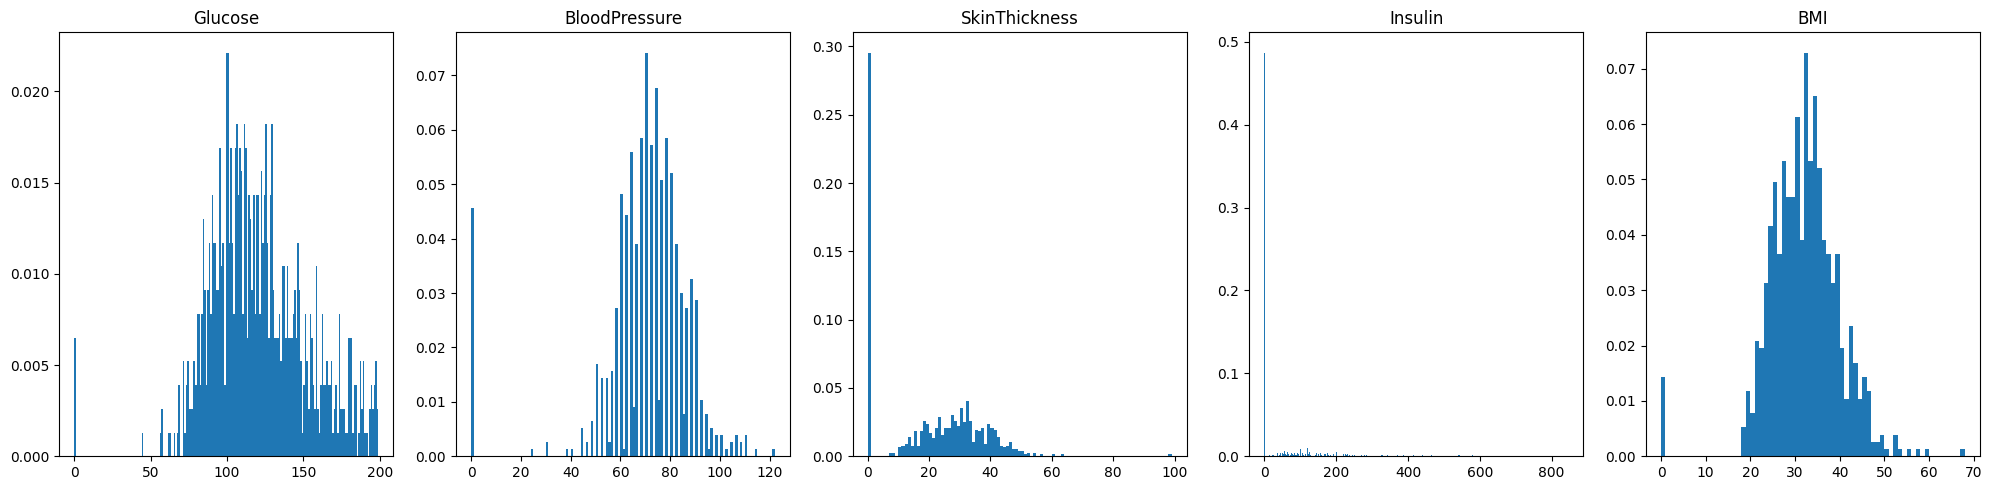

In [7]:
zero_fields = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ii in range(5):
  axes[ii].hist(df[zero_fields[ii]], bins=np.arange(min(df[zero_fields[ii]]), max(df[zero_fields[ii]]) + 1, 1), density=True)
  axes[ii].set_title(zero_fields[ii])
plt.tight_layout()
plt.show()

In [8]:
# lets fix the 0-entry for a field in the dataset with its mean value
def impute_zero_field(data, field):
    # Ensure the column is float to avoid FutureWarning when assigning mean values
    data[field] = data[field].astype(float)
    nonzero_vals = data.loc[data[field] != 0, field]
    avg = np.sum(nonzero_vals) / len(nonzero_vals)
    k = len(data.loc[ data[field] == 0, field])   # num of 0-entries
    data.loc[ data[field] == 0, field] = avg
    print('Field: %s; fixed %d entries with value: %.3f' % (field, k, avg))

# Fix it for Train dataset
for field in zero_fields:
    impute_zero_field(df, field)

Field: Glucose; fixed 5 entries with value: 121.687
Field: BloodPressure; fixed 35 entries with value: 72.405
Field: SkinThickness; fixed 227 entries with value: 29.153
Field: Insulin; fixed 374 entries with value: 155.548
Field: BMI; fixed 11 entries with value: 32.457


In [9]:
df.shape

(768, 9)

# Manipulate the dataset and create the train and target variables

(array([  4.,  19.,  87., 149., 161., 130.,  88.,  54.,  44.,  32.]),
 array([0.22110553, 0.29899497, 0.37688442, 0.45477387, 0.53266332,
        0.61055276, 0.68844221, 0.76633166, 0.84422111, 0.92211055,
        1.        ]),
 <BarContainer object of 10 artists>)

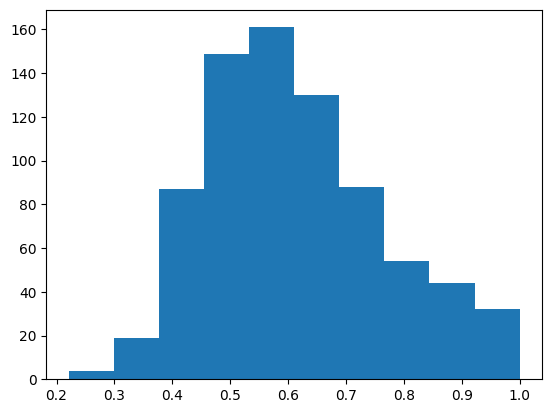

In [10]:
#define the target variable
target_column = ['Outcome']

#create the list of features, after excluding the target variable
predictors = list(set(list(df.columns))-set(target_column))

#normalize the features between 0 and 1 to reduce the influence of the predictor's units and magnitude on the modelling process.
df[predictors] = df[predictors]/df[predictors].max()


plt.hist(df['Glucose'])


In [11]:
X = df[predictors].values
Y = df[target_column].values

#compute the fraction to be used for training and testing (keep 10% for further testing)
fraction = int(X.size/8*0.90)

X_train = X[:fraction,:]
X_test  = X[fraction:,:]

Y_train = Y[:fraction,:]
Y_test  = Y[fraction:,:]

#print(X_train.size, X_test.size)
#print(X_train,Y_train)

In [12]:
#import the needed libraries
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from tensorflow.keras import initializers
from keras.utils import to_categorical

# Build the model

In [13]:
model = Sequential()
model.add(Input((8,)))
model.add(Dense(64, activation='relu', kernel_initializer='random_normal', bias_initializer='zeros'))
#model.add(Dropout(0.2))
model.add(Dense(32, activation='relu', kernel_initializer='random_normal', bias_initializer='zeros'))
#model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid', kernel_initializer='random_normal', bias_initializer='zeros'))

# Compile the model
#lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
#    initial_learning_rate=1e-2,
#    decay_steps=10000,
#    decay_rate=0.9)

#opt = keras.optimizers.Adam(learning_rate=0.001)  #Adam optimizer
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from keras.utils import plot_model

plot_model(model, show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [16]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = model.fit(X_train, Y_train, epochs=100, batch_size=64, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6268 - loss: 0.6914 - val_accuracy: 0.5612 - val_loss: 0.6918
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6739 - loss: 0.6868 - val_accuracy: 0.5612 - val_loss: 0.6905
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6739 - loss: 0.6803 - val_accuracy: 0.5612 - val_loss: 0.6892
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6739 - loss: 0.6719 - val_accuracy: 0.5612 - val_loss: 0.6892
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6739 - loss: 0.6625 - val_accuracy: 0.5612 - val_loss: 0.6926
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6739 - loss: 0.6521 - val_accuracy: 0.5612 - val_loss: 0.6989
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6739 - loss: 0.6474 - val_accuracy: 0.5612 - val_loss: 0.7086
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6739 - loss: 0.6447 - val_accuracy: 0.5612 - val_loss: 0.7127

#Evaluate the model

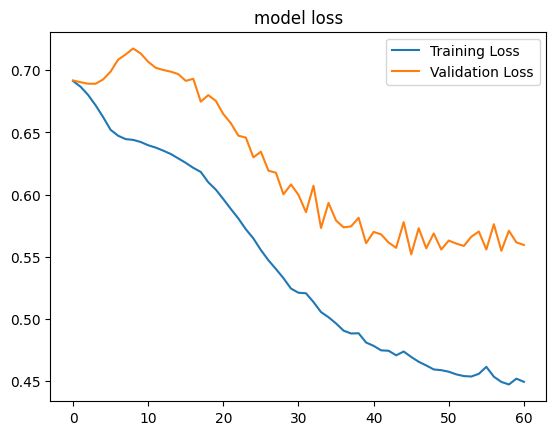

In [17]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title('model loss')
plt.legend()
plt.show()

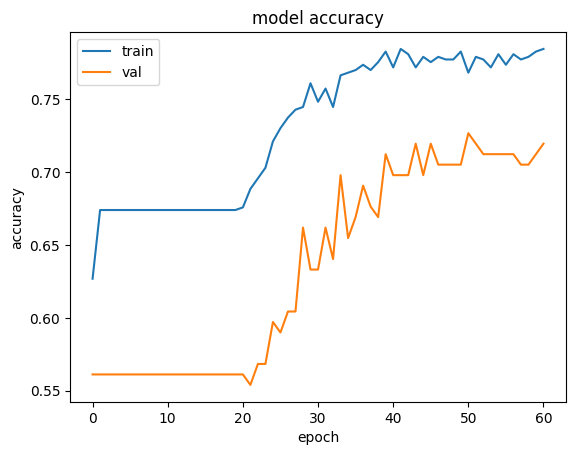

In [18]:
plt.plot(history.history['accuracy'], label="Training accuracy")
plt.plot(history.history['val_accuracy'], label="Validation accuracy")
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step


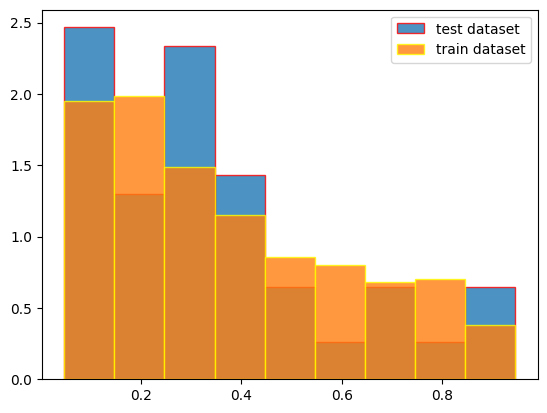

In [19]:
#predict the outcome on the test sample and plot the score
prediction_test = model.predict(X_test)
plt.hist(prediction_test, label='test dataset', alpha=.8, edgecolor='red', bins=np.arange(prediction_test.min(), prediction_test.max() + 0.1, 0.1), density=True)

#predict the outcome on the test sample and plot the score
prediction_train = model.predict(X_train)
plt.hist(prediction_train, label='train dataset', alpha=.8, edgecolor='yellow', bins=np.arange(prediction_test.min(), prediction_test.max() + 0.1, 0.1), density=True)

plt.legend()
plt.show()

In [20]:
print(prediction_test.max())

0.9309547


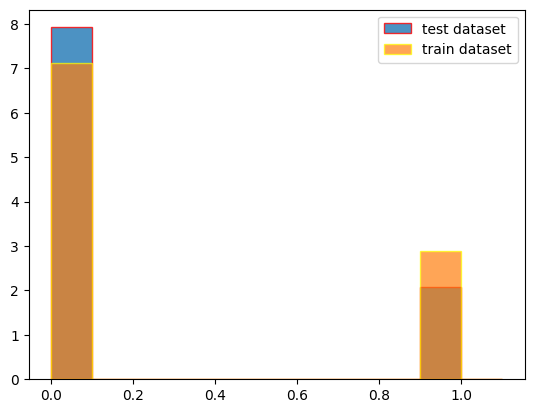

In [21]:
#cast the score to a bool value
prediction_test_rounded = np.round(prediction_test) #cut the score in half
plt.hist(prediction_test_rounded, label='test dataset', alpha=.8, edgecolor='red', bins=np.arange(prediction_test_rounded.min(), prediction_test_rounded.max() + 0.2, 0.1), density=True)

prediction_train_rounded = np.round(prediction_train) #cut the score in half
plt.hist(prediction_train_rounded, label='train dataset', alpha=.7, edgecolor='yellow', bins=np.arange(prediction_test_rounded.min(), prediction_test_rounded.max() + 0.2, 0.1), density=True)

plt.legend()
plt.show()

In [22]:
diff_test = abs(prediction_test_rounded - Y_test)
print('Accuracy on test data: {}'.format(1 - np.sum(diff_test)/diff_test.size))

diff_train = abs(prediction_train_rounded - Y_train)
print('Accuracy on train data: {}'.format(1 - np.sum(diff_train)/diff_train.size))

Accuracy on test data: 0.7272727272727273
Accuracy on train data: 0.7655571635311144


#ROC Curve



The Receiver Operating Characteristic (ROC) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings. The Area Under the Curve (AUC) provides an aggregate measure of performance across all possible classification thresholds. A perfect classifier would have an AUC of 1, while a purely random classifier would have an AUC of 0.5.

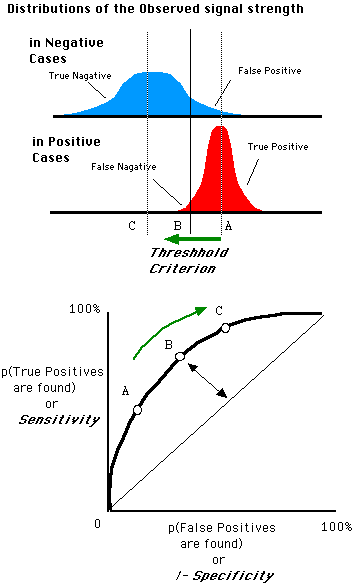

In [24]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

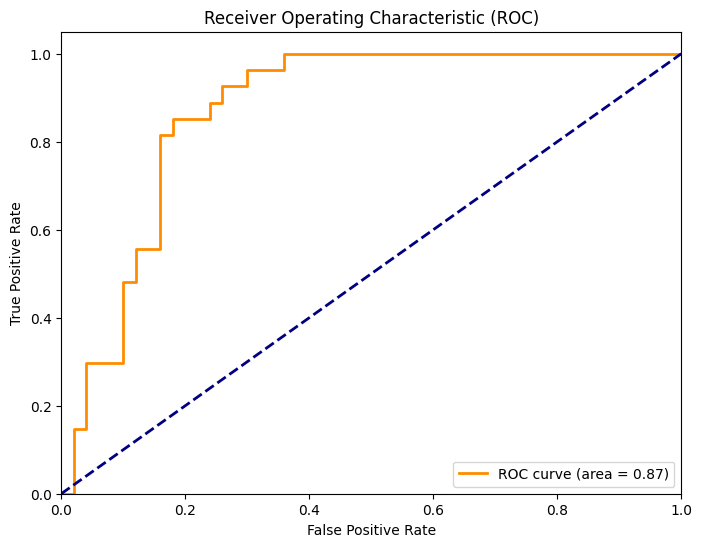

In [25]:
fpr, tpr, thresholds = roc_curve(Y_test, prediction_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

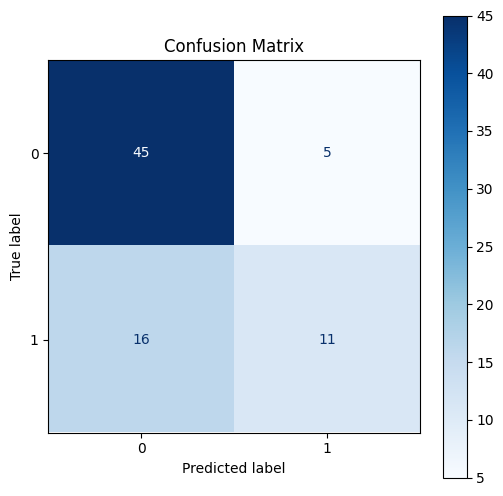

In [26]:
cm = confusion_matrix(Y_test, prediction_test_rounded)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix')
plt.show()